## **Importing Libraries & Data Loading**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/heart.csv')

In [ ]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## **EDA - Exploratory Data Analysis & Data Cleaning**

**Note:** The overall preprocessing steps are the same as those used for the continuous target variable. Since I have already practiced and explained those steps earlier, I will apply all of them together here instead of discussing each one separately.


In [ ]:
df.shape

(918, 12)

In [ ]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [ ]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['HeartDisease'].value_counts()

,count
HeartDisease,
1,508
0,410


The data is equally distributed.

**Note:**
First, I check the **target column**, which is important for categorical data. If one class has significantly more samples than the other (e.g., 850 class `1` and 68 class `0`), the model will learn the majority class better and perform poorly on the minority class. Therefore, we first check whether the target is **balanced** and, if not, apply techniques to balance it.


<Axes: xlabel='HeartDisease'>

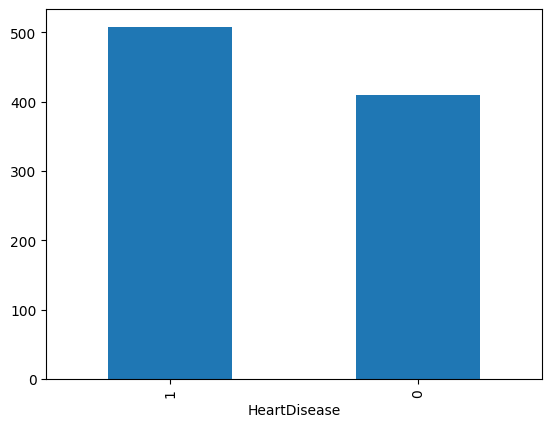

In [ ]:
df['HeartDisease'].value_counts().plot(kind='bar')

In [ ]:
df.isna().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


Everything looks good, and it may seem that we can move directly to data preprocessing since our dataset requires no cleaning. However, let's first analyze the feature distributions.

In [ ]:
def plotting(var,num):
  plt.subplot(3,2,num)
  sns.histplot(df[var], kde=True)

In [ ]:
df.dtypes

,0
Age,int64
Sex,object
ChestPainType,object
RestingBP,int64
Cholesterol,int64
FastingBS,int64
RestingECG,object
MaxHR,int64
ExerciseAngina,object
Oldpeak,float64


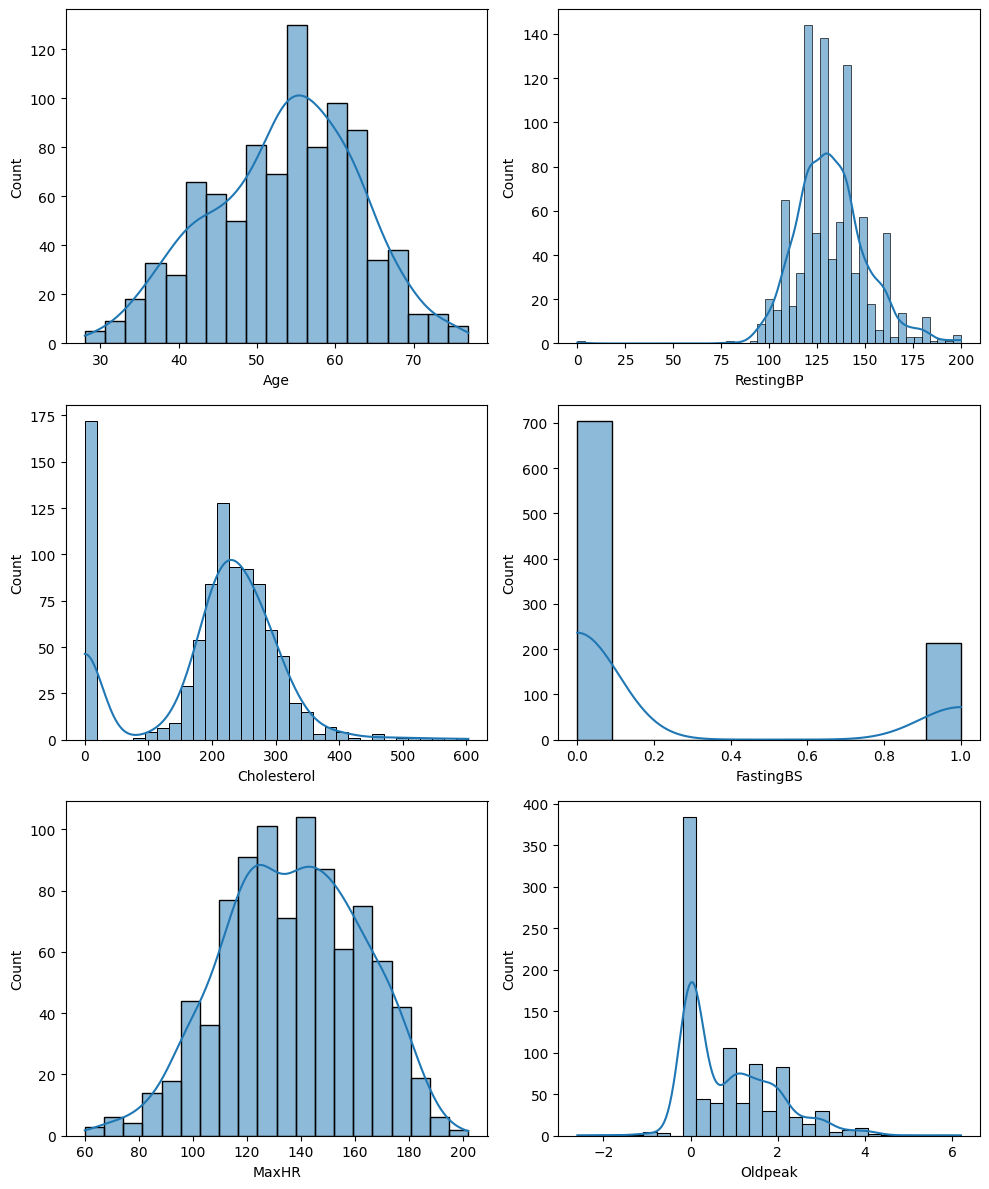

In [ ]:
plt.figure(figsize=(10,12))
plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('FastingBS',4)
plotting('MaxHR',5)
plotting('Oldpeak',6)


plt.tight_layout()


### **Point to Ponder:**
> **The feature distributions also look fine at first glance, so you might think we're ready to move on.**
>
> **But here's the catch:** you're saying this because you haven't researched the features yet. Remember, we cannot move on directly without understanding the data.
>
> For example, if you look at the distribution of **RestingBP**, you'll notice a very small bar at **0**.


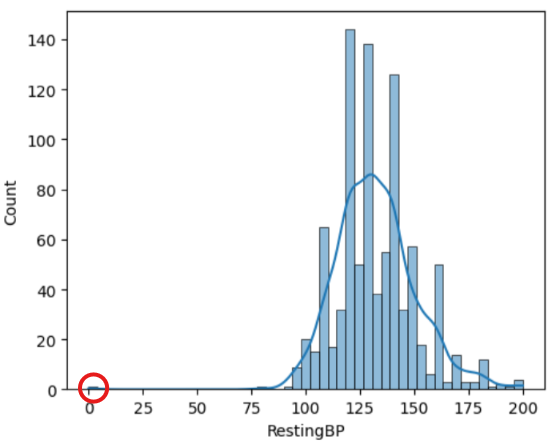

> Now go to Google and search:
>
> **"Can a person have a resting blood pressure of 0?"**
>
> You'll find that the answer is **No**. A resting blood pressure of 0 is not physiologically possible — it would mean the person is not alive.

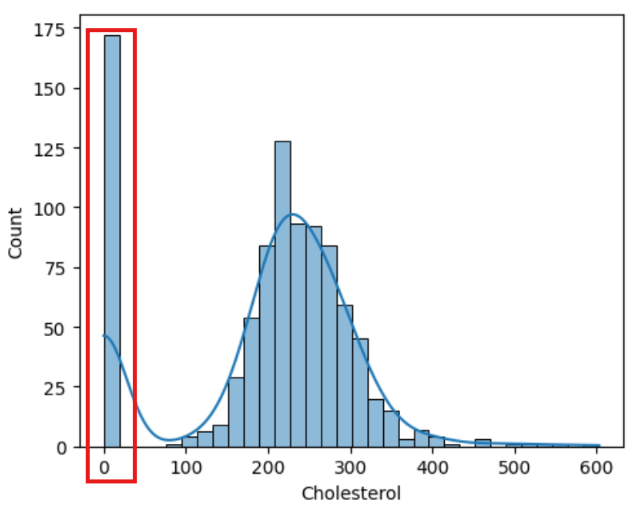

> **Similarly Cholesterol can't be 0**
>
>
> This tells us something very important: **the dataset is syntactically correct (no missing values or format issues), but it is semantically incorrect because some values are logically impossible.**

> **Always remember:** A dataset can look clean, but it may still contain logically invalid values. Always understand the meaning of the features before moving on to preprocessing. Data should be correct not only in structure but also in real-world logic.



So, the moral of the story is: **I don't have any missing values, and I don't have any duplicate values, but I do have logically incorrect (wrongly inserted) values.**

In [ ]:
 df['Cholesterol'].value_counts()

,count
Cholesterol,
0,172
254,11
220,10
223,10
204,9
...,...
353,1
278,1
157,1


**And you can see that `0` has the highest count in Cholestrol. Why does this happen?**
>
> It usually happens because some fields are **mandatory** during data entry. The data entry operator cannot leave those fields empty, so instead of entering a null value, they enter `0`. Since they know that a cholesterol value of `0` is impossible, they use `0` to represent **"no entry"** or **missing data**.

**Due to which the data distribution get distorted.**

In [ ]:
ch_mean = df.loc[df['Cholesterol'] !=0 , 'Cholesterol'].mean()
ch_mean

np.float64(244.6353887399464)

> **So, we'll fill those `0`s with the mean cholesterol value (`ch_mean`). You might think, "Won't this affect the data?" No. Since the rest of the distribution is approximately normal, the mean lies at the center, so replacing the invalid `0`s with it is much better than keeping impossible values in the dataset.**


In [ ]:
df['Cholesterol'] = df['Cholesterol'].replace(0,ch_mean)

In [ ]:
df['Cholesterol'] = df['Cholesterol'].round(2)

<Axes: xlabel='Cholesterol', ylabel='Count'>

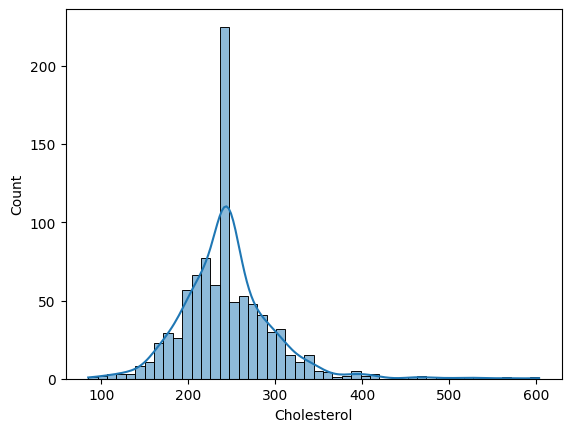

In [ ]:
sns.histplot(df['Cholesterol'], kde=True)

> **Now, we can see values going up to around `600`. So, let's search on Google again:**
>
> **"Can a person have a cholesterol level of 600?"**
>
> **The answer is Yes.** Although it is extremely high and dangerous, it is still medically possible. This means these values are **valid**, so we should keep them in the dataset.

Similarly we will correct our `RestingBP`.

In [ ]:
resting_BP_mean = df.loc[df['RestingBP'] !=0, 'RestingBP'].mean()
resting_BP_mean

np.float64(132.54089422028352)

In [ ]:
df['RestingBP'] = df['RestingBP'].replace(0,resting_BP_mean)

In [ ]:
df['RestingBP'] = df['RestingBP'].round(2)

<Axes: xlabel='RestingBP', ylabel='Count'>

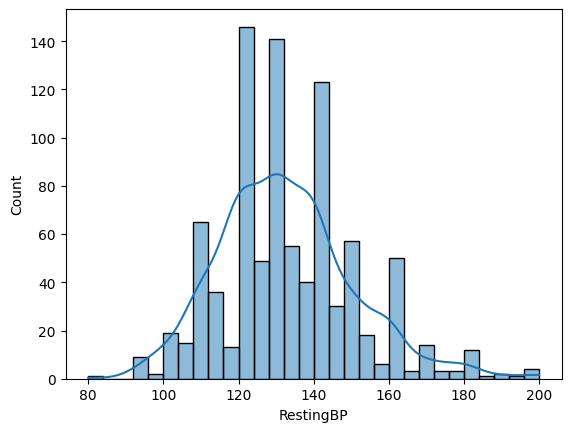

In [ ]:
sns.histplot(df['RestingBP'],kde=True)

Let's import a library `pip install sheryanalysis==0.1.0`

In [ ]:
pip install sheryanalysis==0.1.0

In [ ]:
import sheryanalysis as sh

sh.analyze(df)



🔍 Basic Analysis Report


INFO:sheryanalysis:
🔍 Basic Analysis Report


------------------------------------------------------------


INFO:sheryanalysis:------------------------------------------------------------


📏 Shape: (918, 12)


...


🔠 Categorical Columns: ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'HeartDisease']


INFO:sheryanalysis:
🔠 Categorical Columns: ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'HeartDisease']



🔢 Numerical Columns: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']


INFO:sheryanalysis:
🔢 Numerical Columns: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']


{'shape': (918, 12),
 'columns': ['Age',
  'Sex',
  'ChestPainType',
  'RestingBP',
  'Cholesterol',
  'FastingBS',
  'RestingECG',
  'MaxHR',
  'ExerciseAngina',
  'Oldpeak',
  'ST_Slope',
  'HeartDisease'],
 'dtypes': {'Age': dtype('int64'),
  'Sex': dtype('O'),
  'ChestPainType': dtype('O'),
  'RestingBP': dtype('float64'),
  'Cholesterol': dtype('float64'),
  'FastingBS': dtype('int64'),
  'RestingECG': dtype('O'),
  'MaxHR': dtype('int64'),
  'ExerciseAngina': dtype('O'),
  'Oldpeak': dtype('float64'),
  'ST_Slope': dtype('O'),
  'HeartDisease': dtype('int64')},
 'null_counts': {'Age': 0,
  'Sex': 0,
  'ChestPainType': 0,
  'RestingBP': 0,
  'Cholesterol': 0,
  'FastingBS': 0,
  'RestingECG': 0,
  'MaxHR': 0,
  'ExerciseAngina': 0,
  'Oldpeak': 0,
  'ST_Slope': 0,
  'HeartDisease': 0},
 'total_rows': 918,
 'column_types': {'categorical': ['Sex',
   'ChestPainType',
   'FastingBS',
   'RestingECG',
   'ExerciseAngina',
   'ST_Slope',
   'HeartDisease'],
  'numerical': ['Age', 'Rest

Now let's check Cateogorical Columns

<Axes: xlabel='Sex', ylabel='count'>

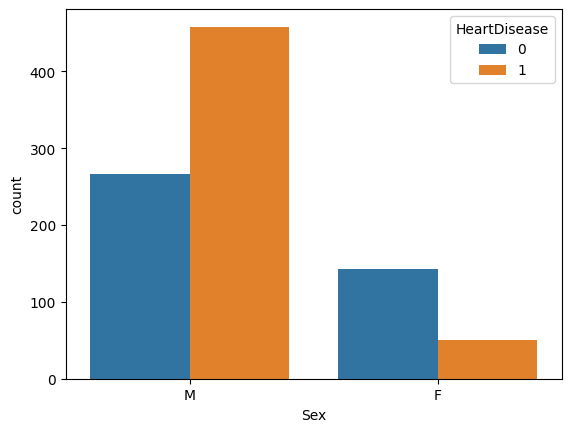

In [ ]:
sns.countplot(x=df['Sex'],hue=df['HeartDisease'])

<Axes: xlabel='ChestPainType', ylabel='count'>

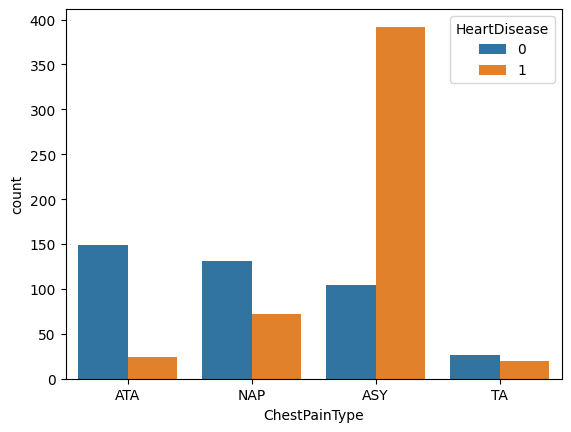

In [ ]:
sns.countplot(x=df['ChestPainType'], hue=df['HeartDisease'])

<Axes: xlabel='FastingBS', ylabel='count'>

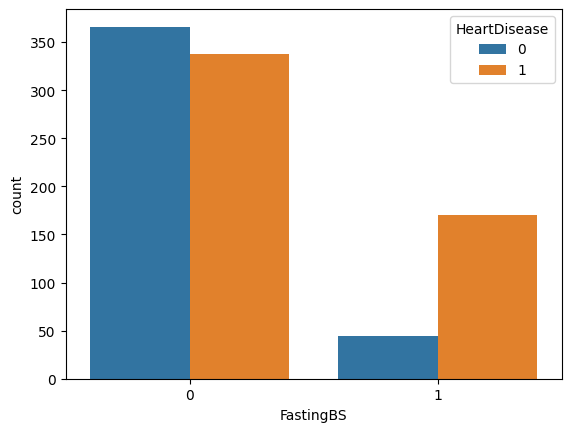

In [ ]:
sns.countplot(x=df['FastingBS'], hue=df['HeartDisease'])

Now we will use boxplot to compare my target categorcal variable with numeric variables

<Axes: xlabel='Cholesterol'>

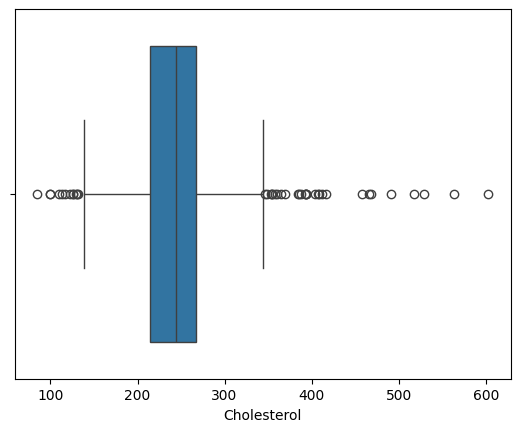

In [ ]:
sns.boxplot(x=df['Cholesterol'], data=df)

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

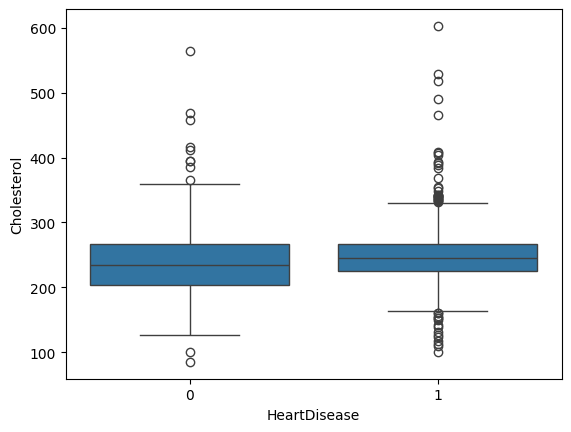

In [ ]:
sns.boxplot(x=df['HeartDisease'], y=df['Cholesterol'], data=df)

<Axes: xlabel='HeartDisease', ylabel='Age'>

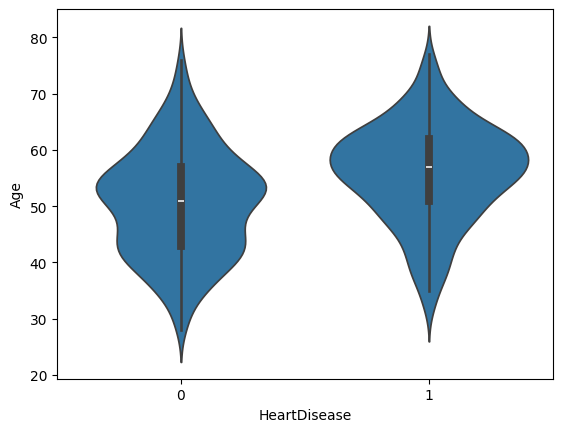

In [ ]:
sns.violinplot(x=df['HeartDisease'], y=df['Age'], data=df)

<Axes: >

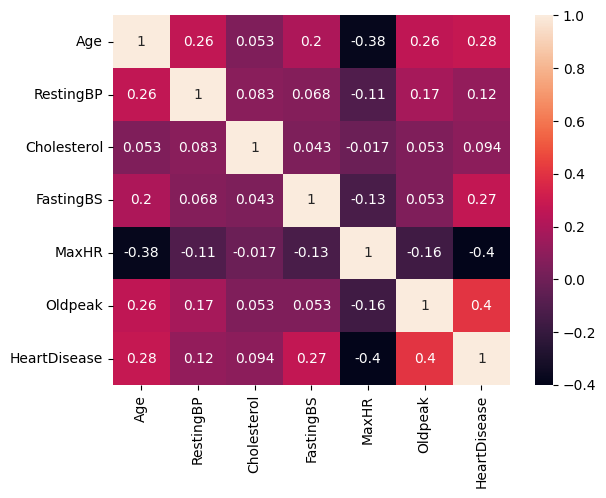

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

## **Data Preprocessing**

In [ ]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0


In [ ]:
# df_encode = pd.get_dummies(df, drop_first=True)
df_encode = pd.get_dummies(df)

*uses one hot encoding to convert categorical data into separate numeric columns*

In [ ]:
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138.0,214.0,0,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150.0,195.0,0,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True


In [ ]:
df_encode = df_encode.astype(int)

In [ ]:
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,0,1,0,...,0,0,0,1,0,1,0,0,0,1
1,49,160,180,0,156,1,1,1,0,0,...,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,0,1,0,...,0,0,0,0,1,1,0,0,0,1
3,48,138,214,0,108,1,1,1,0,1,...,0,0,0,1,0,0,1,0,1,0
4,54,150,195,0,122,0,0,0,1,0,...,1,0,0,1,0,1,0,0,0,1


*Now here we will drop `Sex_F`*

In [ ]:
df_encode = df_encode.drop(columns=['Sex_F'])

In [ ]:
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,0,1,0,0,0,1,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,0,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,0,1,0,0,0,0,1,1,0,0,0,1
3,48,138,214,0,108,1,1,0,1,0,0,0,0,1,0,0,1,0,1,0
4,54,150,195,0,122,0,0,1,0,0,1,0,0,1,0,1,0,0,0,1


In [ ]:
df_encode.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA',
       'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH',
       'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N',
       'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')

**Feature Scaling**

In [ ]:
df_scaled = df_encode.copy()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR' ]

df_scaled[numerical_cols] = scaler.fit_transform(df_scaled[numerical_cols])

scaling between -3 to +3 SPM (Std Points away from Mean)

In [ ]:
df_scaled.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414885,0.834754,0,1.382928,0,0,1,0,1,0,0,0,1,0,1,0,0,0,1
1,-0.478484,1.527224,-1.210675,0,0.754157,1,1,0,0,0,1,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141284,0.722161,0,-1.525138,0,0,1,0,1,0,0,0,0,1,1,0,0,0,1
3,-0.584556,0.303651,-0.572651,0,-1.132156,1,1,0,1,0,0,0,0,1,0,0,1,0,1,0
4,0.051881,0.971054,-0.929194,0,-0.581981,0,0,1,0,0,1,0,0,1,0,1,0,0,0,1


In [ ]:
df_encode.to_csv("heart_final_data.csv")

# **Model Building**

In [ ]:
df = pd.read_csv("heart_final_data.csv")

In [ ]:
df.head()

,Unnamed: 0,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,0,40,140,289,0,172,0,0,1,0,...,0,0,0,1,0,1,0,0,0,1
1,1,49,160,180,0,156,1,1,0,0,...,1,0,0,1,0,1,0,0,1,0
2,2,37,130,283,0,98,0,0,1,0,...,0,0,0,0,1,1,0,0,0,1
3,3,48,138,214,0,108,1,1,0,1,...,0,0,0,1,0,0,1,0,1,0
4,4,54,150,195,0,122,0,0,1,0,...,1,0,0,1,0,1,0,0,0,1


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
# X = df.drop('HeartDisease', axis=1)
X = df.drop(columns='HeartDisease')

y = df['HeartDisease']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

**Note:** *As for distance based algo we'll use scaled data and for others we'll use normal data.*

we can only use scaled data for all model training if using `loop`. It won't make much difference in models which dont required scaling.
But you can not use normal data on all models

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),  # no scaling needed
    "Decision Tree": DecisionTreeClassifier(), # no scaling needed
    "Support Vector Machine": SVC(probability=True),
}

In [ ]:
results = []

In [ ]:
for name, model in models.items():
  # if name == ["Logistic Regression", "K-Nearest Neighbors"]:
  #   model.fit(X_train, y_train)
  # else:
  #   model.fit(X_train_scaled, y_train)

  model.fit(X_train_scaled, y_train)
  y_pred = model.predict(X_test_scaled)

  acc = accuracy_score(y_test,y_pred)
  f1_val = f1_score(y_test,y_pred)
  recall_val = recall_score(y_test,y_pred)

  results.append({
      'model': name,
      'accuracy': round(acc,8),
      'recall_score': round(recall_val,4),
      'f1_score': round(f1_val,4)
  })

Heart Disease → Recall > F1 ≈ Precision > Accuracy

In [ ]:
report = pd.DataFrame(results)

In [ ]:
report

,model,accuracy,recall_score,f1_score
0,Logistic Regression,0.869565,0.8598,0.8846
1,K-Nearest Neighbors,0.869565,0.8598,0.8846
2,Naive Bayes,0.836957,0.8131,0.8529
3,Decision Tree,0.815217,0.7570,0.8265
4,Support Vector Machine,0.869565,0.8692,0.8857


**Result:** SVM performs the best.

# **Export Model**

We export a trained model using **Pickle** or **Joblib**. It serializes the trained model and saves it into a file, usually with a `.pkl` or `.joblib` extension. Later, we can load (deserialize) the saved model and use it to make predictions without training it again.

**Why do we use it?**

Because we can save the trained model once and later provide new input/feature values to the loaded model to get predictions. This is useful when deploying a machine learning model in an application.


In [ ]:
import joblib

joblib.dump(models['Support Vector Machine'], 'SVM_heart.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'columns.pkl')

['columns.pkl']

For deployment, we save the **trained model, scaler, and feature columns** so we can make predictions later using the same preprocessing and feature order.

* `SVM_heart.pkl` → trained SVM model
* `scaler.pkl` → scales new input data in the same way
* `columns.pkl` → maintains the correct feature names and order
